Question 1



First two principal components of wine dataset:
 [[ 3.18562979e+02  2.14921307e+01]
 [ 3.03097420e+02 -5.36471768e+00]
 [ 4.38061133e+02 -6.53730945e+00]
 [ 7.33240139e+02  1.92729032e-01]
 [-1.15714285e+01  1.84899946e+01]]

Explained variance ratio of first two PCs: [0.99809123 0.00173592]

SVM:
Accuracy: 0.708, Precision: 0.680, Recall: 0.683

Decision Tree:
Accuracy: 0.931, Precision: 0.948, Recall: 0.931


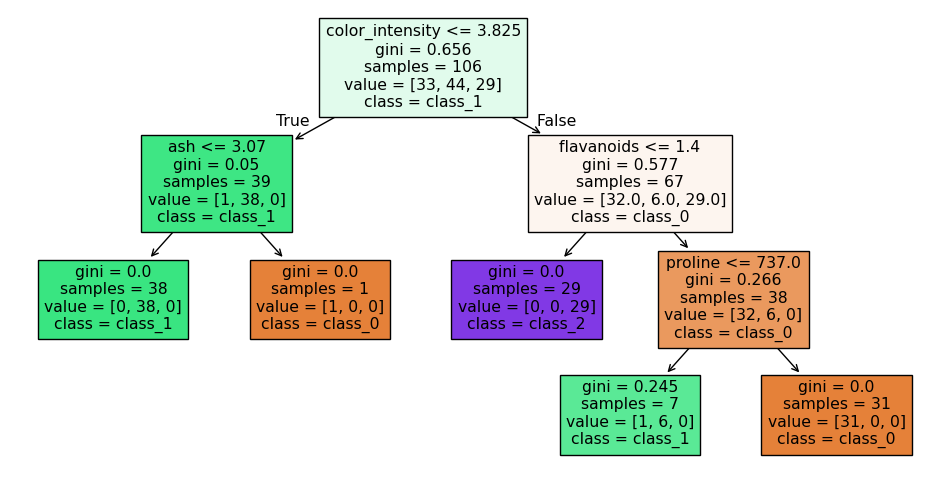

In [12]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt

# load data
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names

# pca algorithm
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# a, limit to 5 rows, long
print("First two principal components of wine dataset:\n", X_pca[:5])

# b, explained variance ratio
explained_variance = pca.explained_variance_ratio_
print("\nExplained variance ratio of first two PCs:", explained_variance)

# c, SVM classifier, wine into three classes
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.4, random_state=42) # use 60/40 per problem def.
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

# get accuracy precision and recall for part d
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, average='macro')
recall_svm = recall_score(y_test, y_pred_svm, average='macro')
print(f"\nSVM:\nAccuracy: {accuracy_svm:.3f}, Precision: {precision_svm:.3f}, Recall: {recall_svm:.3f}")

# d, decision tree calssifier for comparison, using original features
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(X, y, test_size=0.4, random_state=42) # again 60/40 split
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train_dt, y_train_dt)
y_pred_dt = dt.predict(X_test_dt)

# accuracy, precision, and recall comparison compute
accuracy_dt = accuracy_score(y_test_dt, y_pred_dt)
precision_dt = precision_score(y_test_dt, y_pred_dt, average='macro')
recall_dt = recall_score(y_test_dt, y_pred_dt, average='macro')

print(f"\nDecision Tree:\nAccuracy: {accuracy_dt:.3f}, Precision: {precision_dt:.3f}, Recall: {recall_dt:.3f}")

# plotting
plt.figure(figsize=(12,6))
plot_tree(dt, feature_names=feature_names, class_names=wine.target_names, filled=True)
plt.show()


Question 2

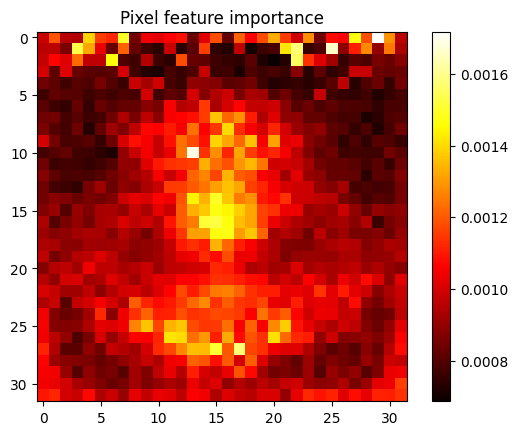

In [3]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt

# load data cifar10 images
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
y_train = y_train.ravel()
y_test = y_test.ravel()

# flatten
X_all = np.concatenate([X_train, X_test], axis=0)
y_all = np.concatenate([y_train, y_test], axis=0)
X_flat = X_all.reshape(X_all.shape[0], -1)

# model
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_flat, y_all)

importances = rf.feature_importances_
importance_image = importances.reshape(32,32,3)

# plotting
plt.imshow(importance_image.sum(axis=2), cmap='hot')
plt.colorbar()
plt.title("Pixel feature importance")
plt.show()

Question 3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step


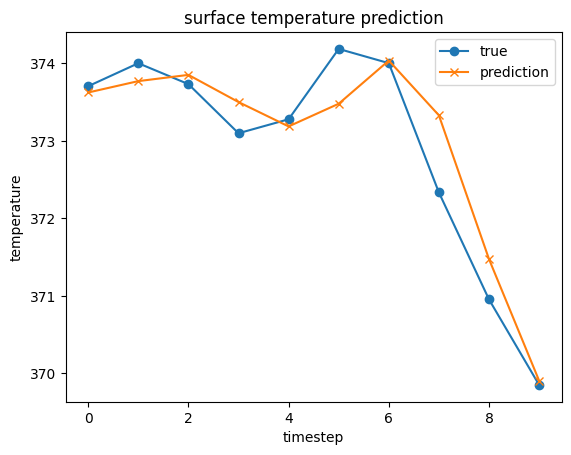

In [9]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# load data
data = np.load('surface_temp.npy')  # shape (1000,)

# scale data
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data.reshape(-1,1))

# use 20 timesteps, preventing overfitting
def create_sequences(data, seq_length=20):
    X, y = [], []
    for i in range(len(data)-seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 20
X_seq, y_seq = create_sequences(data_scaled, seq_length)

# split data
X_train, y_train = X_seq[:-10], y_seq[:-10]
X_pred, y_true = X_seq[-10:], y_seq[-10:]

# model params
model = Sequential([
    SimpleRNN(64, activation='tanh', input_shape=(seq_length,1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=200, verbose=0)

# prediction
y_pred = model.predict(X_pred)
y_pred_rescaled = scaler.inverse_transform(y_pred)
y_true_rescaled = scaler.inverse_transform(y_true)

# plotting
plt.plot(range(10), y_true_rescaled, 'o-', label='true')
plt.plot(range(10), y_pred_rescaled, 'x-', label='prediction')
plt.xlabel('timestep')
plt.ylabel('temperature')
plt.title('surface temperature prediction')
plt.legend()
plt.show()
